# 📊 Análise dos Reembolsos da CEAPS
## Exercício 2023

**Autor:** Claudio Amaro

---

### Objetivo

Realizar uma análise exploratória dos reembolsos da Cota para o Exercício da Atividade Parlamentar dos Senadores (CEAPS), utilizando técnicas de Ciência de Dados para identificar padrões, indicadores e tendências dos gastos públicos.

---

### Tecnologias

- Python
- Pandas
- NumPy
- Plotly
- Jupyter Notebook

# Sumário

1. Importação das Bibliotecas

2. Importação dos Dados

3. Limpeza dos Dados

4. Análise Exploratória (EDA)

5. KPIs

6. Análise por Categoria

7. Top 10 Senadores

8. Top 10 Fornecedores

9. Evolução Mensal

10. Heatmap

11. Dashboard Executivo

12. Análise Executiva

13. Principais Insights

14. Conclusão

15. Exportação

# 1. Importação das Bibliotecas

In [19]:
import pandas as pd
import numpy as np

import plotly
import importlib.metadata
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

import os
os.makedirs("images", exist_ok=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)

# 2. Importação dos Dados

In [22]:
arquivo = r'C:\Users\PC\Documents\DadosCEAPS\ceaps-eda-2023\despesas_ceaps_2023.csv'

df = pd.read_csv(
    arquivo,
    sep=';',
    decimal=',',
    thousands='.'
)
print(f"Quantidade de registros: {len(df):,}")

Quantidade de registros: 18,824


In [24]:
print("="*60)
print("ESTATÍSTICAS")
display(df.describe(include='all'))

ESTATÍSTICAS


,ID,TIPO_DOCUMENTO,ANO,MÊS,COD_SENADOR,NOME_SENADOR,TIPO_DESPESA,CPF_CNPJ_FORNECEDOR,NOME_FORNECEDOR,DOCUMENTO,DATA,DETALHAMENTO,VALOR_REEMBOLSADO
count,"18,824.00",18824,"18,824.00","18,824.00","18,824.00",18824,18727,18824,18824,18083,18824,8453,"18,824.00"
unique,NaN,7,NaN,NaN,NaN,100,7,3276,3520,14842,436,4987,NaN
top,NaN,Nota Fiscal Eletrônica,NaN,NaN,NaN,HUMBERTO COSTA,"Locomoção, hospedagem, alimentação, combustíve...",06.064.175/0001-49,Aires Turismo,"2,023E+14",01/06/2023,DESPESA COM COMBUSTÍVEL EM VEÍCULOS UTILIZADOS...,NaN
freq,NaN,8739,NaN,NaN,NaN,636,7544,2052,1601,228,138,259,NaN
mean,"2,206,107.18",NaN,"2,023.00",6.89,"4,553.48",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,541.86"
std,"7,995.39",NaN,0.00,3.31,"2,162.73",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"3,476.27"
min,"2,192,352.00",NaN,"2,023.00",1.00,22.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"-2,588.68"
25%,"2,199,036.75",NaN,"2,023.00",4.00,"3,806.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,184.00
50%,"2,205,975.50",NaN,"2,023.00",7.00,"5,672.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,439.23
75%,"2,213,130.25",NaN,"2,023.00",10.00,"5,990.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,706.25"


# 3. Limpeza dos Dados

In [27]:
# Remove espaços dos nomes das colunas
df.columns = df.columns.str.strip()

# Remove registros sem valor reembolsado
df = df.dropna(subset=["VALOR_REEMBOLSADO"])

# Converte a data
df["DATA"] = pd.to_datetime(
    df["DATA"],
    errors="coerce",
    dayfirst=True
)

# Remove datas inválidas
df = df.dropna(subset=["DATA"])

# Cria colunas auxiliares
df["ANO"] = df["DATA"].dt.year
df["MÊS"] = df["DATA"].dt.month

print("Limpeza concluída!")
print(df.shape)

Limpeza concluída!
(18824, 13)


In [29]:
total_gasto = df['VALOR_REEMBOLSADO'].sum()

media_gasto = df['VALOR_REEMBOLSADO'].mean()

total_senadores = df['NOME_SENADOR'].nunique()

total_fornecedores = df['NOME_FORNECEDOR'].nunique()

print(f'Total gasto: R$ {total_gasto:,.2f}')
print(f'Média por lançamento: R$ {media_gasto:,.2f}')
print(f'Senadores: {total_senadores}')
print(f'Fornecedores: {total_fornecedores}')

Total gasto: R$ 29,023,912.97
Média por lançamento: R$ 1,541.86
Senadores: 100
Fornecedores: 3520


# 4. Criação dos DataFrames Analíticos

Nesta etapa são construídos os DataFrames que servirão de base para todas as análises, indicadores e visualizações do projeto.

A centralização dessa preparação torna o notebook mais organizado, facilita a manutenção do código e permite a reutilização da estrutura em análises futuras.

In [55]:
total_gasto = df['VALOR_REEMBOLSADO'].sum()

media_gasto = df['VALOR_REEMBOLSADO'].mean()

total_senadores = df['NOME_SENADOR'].nunique()

total_fornecedores = df['NOME_FORNECEDOR'].nunique()

print(f'Total gasto: R$ {total_gasto:,.2f}')
print(f'Média por lançamento: R$ {media_gasto:,.2f}')
print(f'Senadores: {total_senadores}')
print(f'Fornecedores: {total_fornecedores}')

Total gasto: R$ 29,023,912.97
Média por lançamento: R$ 1,541.86
Senadores: 100
Fornecedores: 3520


In [57]:
# =====================================================
# DataFrame - Categorias de Despesas
# =====================================================

despesas_categoria = (
    df.groupby("TIPO_DESPESA", as_index=False)
      .agg(
          TOTAL=("VALOR_REEMBOLSADO", "sum"),
          MEDIA=("VALOR_REEMBOLSADO", "mean"),
          QUANTIDADE=("VALOR_REEMBOLSADO", "count")
      )
      .sort_values("TOTAL", ascending=False)
)

despesas_categoria["PERCENTUAL"] = (
    despesas_categoria["TOTAL"]
    / despesas_categoria["TOTAL"].sum()
    * 100
).round(2)

# =====================================================
# DataFrame - Top Senadores
# =====================================================

top_senadores = (
    df.groupby("NOME_SENADOR", as_index=False)
      .agg(
          TOTAL=("VALOR_REEMBOLSADO", "sum"),
          MEDIA=("VALOR_REEMBOLSADO", "mean"),
          QUANTIDADE=("VALOR_REEMBOLSADO", "count")
      )
      .sort_values("TOTAL", ascending=False)
      .head(10)
)

# =====================================================
# DataFrame - Top Fornecedores
# =====================================================

top_fornecedores = (
    df.groupby("NOME_FORNECEDOR", as_index=False)
      .agg(
          TOTAL=("VALOR_REEMBOLSADO", "sum"),
          MEDIA=("VALOR_REEMBOLSADO", "mean"),
          QUANTIDADE=("VALOR_REEMBOLSADO", "count")
      )
      .sort_values("TOTAL", ascending=False)
      .head(10)
)

# =====================================================
# DataFrame - Gastos Mensais
# =====================================================

gastos_mes = (
    df.groupby("MÊS", as_index=False)
      .agg(
          TOTAL=("VALOR_REEMBOLSADO", "sum")
      )
)

meses = {
    1:"Jan",
    2:"Fev",
    3:"Mar",
    4:"Abr",
    5:"Mai",
    6:"Jun",
    7:"Jul",
    8:"Ago",
    9:"Set",
    10:"Out",
    11:"Nov",
    12:"Dez"
}

gastos_mes["MES_NOME"] = gastos_mes["MÊS"].map(meses)

gastos_mes = gastos_mes.sort_values("MÊS")

# =====================================================
# DataFrame - Heatmap
# =====================================================

heatmap = df.pivot_table(

    values="VALOR_REEMBOLSADO",

    index="TIPO_DESPESA",

    columns="MÊS",

    aggfunc="sum",

    fill_value=0

)



# 5. Análise explanatória dos Dados (EDA)

In [60]:
# =====================================================
# Análise Exploratória dos Dados (EDA)
# =====================================================

from IPython.display import display

print("=" * 80)
print("ANÁLISE EXPLORATÓRIA DOS DADOS (EDA)")
print("=" * 80)

# -----------------------------------------------------
# Dimensões do DataFrame
# -----------------------------------------------------

print(f"\nNúmero de linhas : {df.shape[0]:,}")
print(f"Número de colunas: {df.shape[1]}")

# -----------------------------------------------------
# Primeiros registros
# -----------------------------------------------------

print("\n" + "=" * 80)
print("PRIMEIROS REGISTROS")
print("=" * 80)

display(df.head())

# -----------------------------------------------------
# Informações gerais
# -----------------------------------------------------

print("\n" + "=" * 80)
print("INFORMAÇÕES DO DATAFRAME")
print("=" * 80)

df.info()

# -----------------------------------------------------
# Tipos das variáveis
# -----------------------------------------------------

print("\n" + "=" * 80)
print("TIPOS DAS VARIÁVEIS")
print("=" * 80)

display(
    df.dtypes.rename("Tipo").to_frame()
)

# -----------------------------------------------------
# Estatísticas descritivas
# -----------------------------------------------------

print("\n" + "=" * 80)
print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 80)

display(df.describe(include="all"))

ANÁLISE EXPLORATÓRIA DOS DADOS (EDA)

Número de linhas : 18,824
Número de colunas: 13

PRIMEIROS REGISTROS


,ID,TIPO_DOCUMENTO,ANO,MÊS,COD_SENADOR,NOME_SENADOR,TIPO_DESPESA,CPF_CNPJ_FORNECEDOR,NOME_FORNECEDOR,DOCUMENTO,DATA,DETALHAMENTO,VALOR_REEMBOLSADO
0,2203190,Nota Fiscal Eletrônica,2023,6,6027,MECIAS DE JESUS,Aquisição de material de consumo para uso no e...,05.059.252/0001-00,CopyNet Mourão e Lira LTDA- EPP,º. 000.021.535,2023-06-28,NaN,38.30
1,2203185,Nota Fiscal Eletrônica,2023,6,6027,MECIAS DE JESUS,Aquisição de material de consumo para uso no e...,05.059.252/0001-00,CopyNet Mourão e Lira LTDA- EPP,000.021.532,2023-06-28,NaN,41.50
2,2203184,Nota Fiscal Eletrônica,2023,6,6027,MECIAS DE JESUS,Aquisição de material de consumo para uso no e...,05.059.252/0001-00,CopyNet Mourão e Lira LTDA- EPP,000.021.537,2023-06-28,NaN,47.30
3,2203183,Nota Fiscal Eletrônica,2023,6,6027,MECIAS DE JESUS,Aquisição de material de consumo para uso no e...,05.059.252/0001-00,CopyNet Mourão e Lira LTDA- EPP,000.021.539,2023-06-28,NaN,51.00
4,2203188,Nota Fiscal Eletrônica,2023,6,6027,MECIAS DE JESUS,Aquisição de material de consumo para uso no e...,05.059.252/0001-00,CopyNet Mourão e Lira LTDA- EPP,000.021.536,2023-06-28,NaN,77.10



INFORMAÇÕES DO DATAFRAME
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18824 entries, 0 to 18823
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   18824 non-null  int64         
 1   TIPO_DOCUMENTO       18824 non-null  object        
 2   ANO                  18824 non-null  int32         
 3   MÊS                  18824 non-null  int32         
 4   COD_SENADOR          18824 non-null  int64         
 5   NOME_SENADOR         18824 non-null  object        
 6   TIPO_DESPESA         18727 non-null  object        
 7   CPF_CNPJ_FORNECEDOR  18824 non-null  object        
 8   NOME_FORNECEDOR      18824 non-null  object        
 9   DOCUMENTO            18083 non-null  object        
 10  DATA                 18824 non-null  datetime64[ns]
 11  DETALHAMENTO         8453 non-null   object        
 12  VALOR_REEMBOLSADO    18824 non-null  float64       
dtypes: da

,Tipo
ID,int64
TIPO_DOCUMENTO,object
ANO,int32
MÊS,int32
COD_SENADOR,int64
NOME_SENADOR,object
TIPO_DESPESA,object
CPF_CNPJ_FORNECEDOR,object
NOME_FORNECEDOR,object
DOCUMENTO,object



ESTATÍSTICAS DESCRITIVAS


,ID,TIPO_DOCUMENTO,ANO,MÊS,COD_SENADOR,NOME_SENADOR,TIPO_DESPESA,CPF_CNPJ_FORNECEDOR,NOME_FORNECEDOR,DOCUMENTO,DATA,DETALHAMENTO,VALOR_REEMBOLSADO
count,"18,824.00",18824,"18,824.00","18,824.00","18,824.00",18824,18727,18824,18824,18083,18824,8453,"18,824.00"
unique,NaN,7,NaN,NaN,NaN,100,7,3276,3520,14842,NaN,4987,NaN
top,NaN,Nota Fiscal Eletrônica,NaN,NaN,NaN,HUMBERTO COSTA,"Locomoção, hospedagem, alimentação, combustíve...",06.064.175/0001-49,Aires Turismo,"2,023E+14",NaN,DESPESA COM COMBUSTÍVEL EM VEÍCULOS UTILIZADOS...,NaN
freq,NaN,8739,NaN,NaN,NaN,636,7544,2052,1601,228,NaN,259,NaN
mean,"2,206,107.18",NaN,"2,022.99",6.76,"4,553.48",NaN,NaN,NaN,NaN,NaN,2023-07-07 03:02:49.825754368,NaN,"1,541.86"
min,"2,192,352.00",NaN,"1,973.00",1.00,22.00,NaN,NaN,NaN,NaN,NaN,1973-11-20 00:00:00,NaN,"-2,588.68"
25%,"2,199,036.75",NaN,"2,023.00",4.00,"3,806.00",NaN,NaN,NaN,NaN,NaN,2023-04-16 00:00:00,NaN,184.00
50%,"2,205,975.50",NaN,"2,023.00",7.00,"5,672.00",NaN,NaN,NaN,NaN,NaN,2023-07-09 00:00:00,NaN,439.23
75%,"2,213,130.25",NaN,"2,023.00",10.00,"5,990.00",NaN,NaN,NaN,NaN,NaN,2023-10-04 00:00:00,NaN,"1,706.25"
max,"2,226,335.00",NaN,"2,024.00",12.00,"6,369.00",NaN,NaN,NaN,NaN,NaN,2024-04-23 00:00:00,NaN,"105,000.00"


## Principais Observações

- A base de dados contém **18.824 registros** após a etapa de limpeza, representando os reembolsos da CEAPS realizados no exercício de 2023.

- Não foram identificados valores ausentes nas variáveis essenciais para a análise. As poucas inconsistências encontradas nas datas foram corrigidas diretamente na base de dados antes do processamento.

- O conjunto de dados apresenta variáveis categóricas (senador, fornecedor e tipo de despesa) e variáveis numéricas (valor reembolsado), permitindo diferentes perspectivas de análise.

- A qualidade dos dados é adequada para a construção dos indicadores, visualizações e análises executivas apresentadas nas próximas etapas.

# 6. KPIs Executivos

Os indicadores abaixo apresentam uma visão consolidada da execução da CEAPS em 2023, resumindo as principais métricas obtidas após o processamento dos dados.

In [64]:
# ==============================
# Categorias
# ==============================

despesas_categoria = (
    df.groupby('TIPO_DESPESA', as_index=False)
      .agg(
          TOTAL=('VALOR_REEMBOLSADO','sum'),
          MEDIA=('VALOR_REEMBOLSADO','mean'),
          QUANTIDADE=('VALOR_REEMBOLSADO','count')
      )
      .sort_values('TOTAL', ascending=False)
)

despesas_categoria['PERCENTUAL'] = (
    despesas_categoria['TOTAL']
    / despesas_categoria['TOTAL'].sum()
    *100
).round(2)


# ==============================
# Top Senadores
# ==============================

top_senadores = (
    df.groupby('NOME_SENADOR', as_index=False)
      .agg(
          TOTAL=('VALOR_REEMBOLSADO','sum'),
          MEDIA=('VALOR_REEMBOLSADO','mean'),
          QUANTIDADE=('VALOR_REEMBOLSADO','count')
      )
      .sort_values('TOTAL', ascending=False)
      .head(10)
)


# ==============================
# Top Fornecedores
# ==============================

top_fornecedores = (
    df.groupby('NOME_FORNECEDOR', as_index=False)
      .agg(
          TOTAL=('VALOR_REEMBOLSADO','sum'),
          MEDIA=('VALOR_REEMBOLSADO','mean'),
          QUANTIDADE=('VALOR_REEMBOLSADO','count')
      )
      .sort_values('TOTAL', ascending=False)
      .head(10)
)


# ==============================
# Gastos Mensais
# ==============================

gastos_mes = (
    df.groupby('MÊS', as_index=False)
      .agg(
          TOTAL=('VALOR_REEMBOLSADO', 'sum')
      )
)

nomes = {
1:'Jan',
2:'Fev',
3:'Mar',
4:'Abr',
5:'Mai',
6:'Jun',
7:'Jul',
8:'Ago',
9:'Set',
10:'Out',
11:'Nov',
12:'Dez'
}

gastos_mes['MES_NOME'] = gastos_mes['MÊS'].map(nomes)


# ==============================
# Heatmap
# ==============================

heatmap = df.pivot_table(
    values='VALOR_REEMBOLSADO',
    index='TIPO_DESPESA',
    columns='MÊS',
    aggfunc='sum'
)

print("DataFrames para próximas análises criados com sucesso!")

DataFrames para próximas análises criados com sucesso!


In [66]:
# =====================================================
# KPIs EXECUTIVOS
# =====================================================

# Maior categoria
maior_categoria = despesas_categoria.loc[
    despesas_categoria["TOTAL"].idxmax(), "TIPO_DESPESA"
]

# Maior senador
maior_senador = top_senadores.loc[
    top_senadores["TOTAL"].idxmax(), "NOME_SENADOR"
]

# Maior fornecedor
maior_fornecedor = top_fornecedores.loc[
    top_fornecedores["TOTAL"].idxmax(), "NOME_FORNECEDOR"
]

# Mês de maior gasto
maior_mes = gastos_mes.loc[
    gastos_mes["TOTAL"].idxmax(), "MES_NOME"
]

# DataFrame de KPIs
kpis = pd.DataFrame({
    "Indicador": [
        "💰 Total Reembolsado",
        "📄 Quantidade de Despesas",
        "👤 Senadores",
        "🏢 Fornecedores",
        "📊 Ticket Médio",
        "🥇 Maior Categoria",
        "🏛️ Maior Senador",
        "✈️ Maior Fornecedor",
        "📅 Mês de Maior Gasto"
    ],

    "Valor": [
        f"R$ {df['VALOR_REEMBOLSADO'].sum():,.2f}",
        f"{len(df):,}",
        df["NOME_SENADOR"].nunique(),
        df["NOME_FORNECEDOR"].nunique(),
        f"R$ {df['VALOR_REEMBOLSADO'].mean():,.2f}",
        maior_categoria,
        maior_senador,
        maior_fornecedor,
        maior_mes
    ]
})

display(kpis)

,Indicador,Valor
0,💰 Total Reembolsado,"R$ 29,023,912.97"
1,📄 Quantidade de Despesas,"18,824"
2,👤 Senadores,100
3,🏢 Fornecedores,3520
4,📊 Ticket Médio,"R$ 1,541.86"
5,🥇 Maior Categoria,"Contratação de consultorias, assessorias, pesq..."
6,🏛️ Maior Senador,OMAR AZIZ
7,✈️ Maior Fornecedor,Aires Turismo
8,📅 Mês de Maior Gasto,Dez


## Principais Observações

- Os KPIs sintetizam os principais indicadores do exercício de 2023, permitindo uma visão rápida da execução da CEAPS.

- O valor total reembolsado, o ticket médio e a quantidade de despesas demonstram a dimensão financeira da base analisada.

- A identificação da categoria, do senador, do fornecedor e do mês de maior gasto auxilia na compreensão dos padrões predominantes de utilização dos recursos.

- Esses indicadores servem como base para as análises detalhadas apresentadas nas seções seguintes.

# 7. Análise das Categorias de Despesas

Nesta seção são analisadas as categorias de despesas reembolsadas pela CEAPS durante o exercício de 2023.

O objetivo é identificar quais grupos de despesas concentraram a maior parte dos recursos públicos, permitindo compreender a distribuição dos gastos e os padrões de utilização da cota parlamentar.

In [70]:
display(despesas_categoria)

,TIPO_DESPESA,TOTAL,MEDIA,QUANTIDADE,PERCENTUAL
2,"Contratação de consultorias, assessorias, pesq...","7,165,283.72","3,803.23",1884,24.88
4,"Locomoção, hospedagem, alimentação, combustíve...","6,557,745.24",869.27,7544,22.77
5,"Passagens aéreas, aquáticas e terrestres nacio...","5,403,740.80","1,733.64",3117,18.76
0,"Aluguel de imóveis para escritório político, c...","4,423,393.23","1,249.19",3541,15.36
3,Divulgação da atividade parlamentar,"4,253,144.87","3,109.02",1368,14.77
1,Aquisição de material de consumo para uso no e...,"992,091.57",787.37,1260,3.44
6,Serviços de Segurança Privada,"3,908.70",300.67,13,0.01


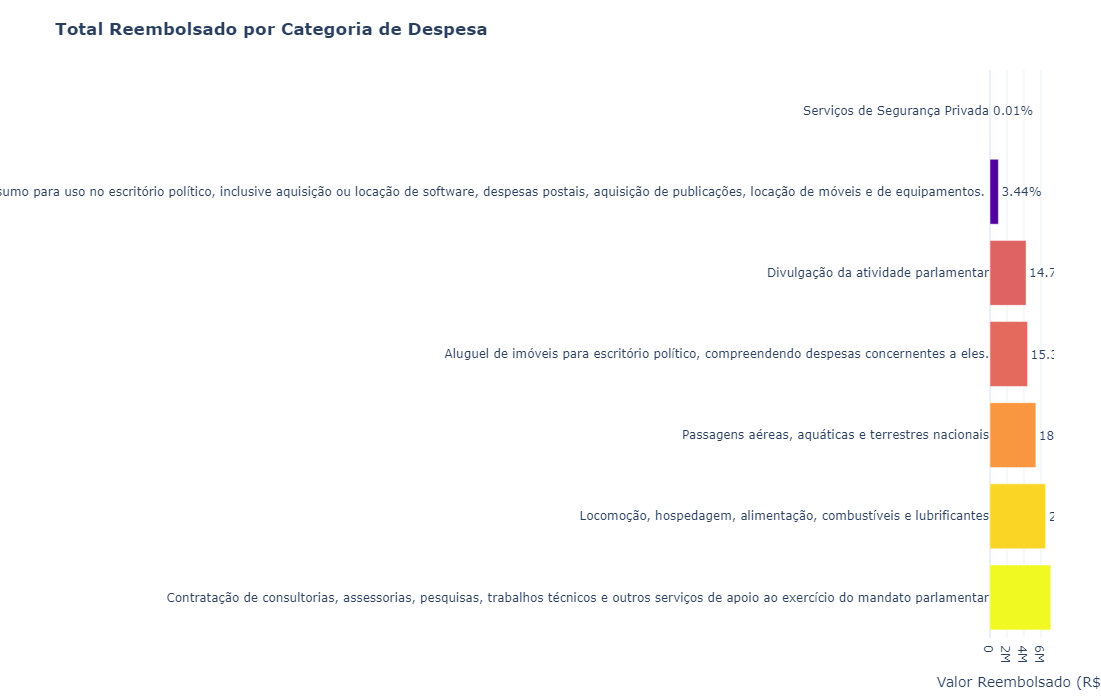

In [72]:
# =====================================================
# Gráfico - Categorias
# =====================================================

import plotly.express as px

fig_categoria = px.bar(

    despesas_categoria,

    x="TOTAL",
    y="TIPO_DESPESA",

    orientation="h",

    text="PERCENTUAL",

    color="TOTAL",

    template="plotly_white",

    title="<b>Total Reembolsado por Categoria de Despesa</b>"
)

fig_categoria.update_traces(

    texttemplate="%{text:.2f}%",
    textposition="outside"

)

fig_categoria.update_layout(

    height=700,

    yaxis_title="",

    xaxis_title="Valor Reembolsado (R$)",

    coloraxis_showscale=False,

    margin=dict(
        l=250,
        r=50,
        t=70,
        b=40
    )

)

fig_categoria.show()

## Análise das Categorias

A distribuição dos reembolsos evidencia que os recursos da CEAPS concentram-se em um número reduzido de categorias de despesas, refletindo os principais custos associados ao exercício da atividade parlamentar.

As categorias de maior participação representam despesas diretamente relacionadas ao funcionamento dos gabinetes, deslocamentos, comunicação institucional e contratação de serviços especializados, demonstrando que essas áreas absorvem a maior parcela do orçamento executado.

## Principais Achados

- A maior parte dos recursos concentrou-se nas principais categorias de despesas.

- Consultorias, passagens, locomoção, hospedagem e divulgação parlamentar permaneceram entre os maiores grupos de gastos.

- As categorias com menor participação representaram apenas uma pequena parcela do total reembolsado.

- Observa-se uma distribuição compatível com a natureza operacional da atividade parlamentar.

## Conclusões

A análise por categoria demonstra que os reembolsos da CEAPS apresentam forte concentração em despesas essenciais ao funcionamento da atividade parlamentar.

Esses resultados fornecem uma base consistente para comparações com exercícios anteriores e posteriores, permitindo avaliar a evolução da composição dos gastos públicos ao longo do tempo.

# 8. Análise dos Senadores

Esta seção apresenta os senadores que concentraram os maiores valores reembolsados pela CEAPS durante o exercício de 2023.

O objetivo é identificar a distribuição dos recursos entre os parlamentares e destacar aqueles com maior volume de despesas reembolsadas.

In [81]:
display(top_senadores)

,NOME_SENADOR,TOTAL,MEDIA,QUANTIDADE
68,OMAR AZIZ,"560,388.62","8,364.01",67
75,RANDOLFE RODRIGUES,"539,369.79","2,631.07",205
19,DAVI ALCOLUMBRE,"537,080.00","8,391.88",64
80,ROGÉRIO CARVALHO,"528,813.13","2,448.21",216
65,MECIAS DE JESUS,"513,042.28","5,029.83",102
54,LUCAS BARRETO,"509,700.04","1,704.68",299
2,ALESSANDRO VIEIRA,"501,046.30","2,492.77",201
52,LAÉRCIO OLIVEIRA,"492,701.94","1,778.71",277
12,CHICO RODRIGUES,"491,174.98","3,807.56",129
59,MARCIO BITTAR,"479,352.20","9,782.70",49


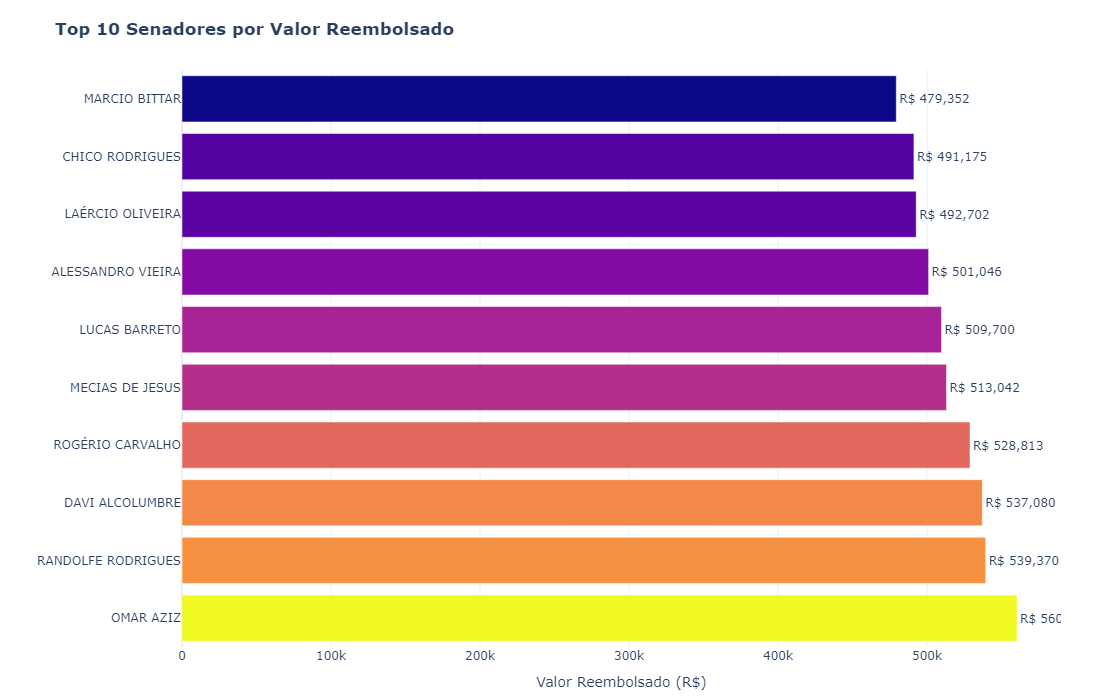

In [83]:
import plotly.express as px

fig_senadores = px.bar(

    top_senadores,

    x="TOTAL",
    y="NOME_SENADOR",

    orientation="h",

    text="TOTAL",

    color="TOTAL",

    template="plotly_white",

    title="<b>Top 10 Senadores por Valor Reembolsado</b>"
)

fig_senadores.update_traces(

    texttemplate="R$ %{text:,.0f}",
    textposition="outside"

)

fig_senadores.update_layout(

    height=700,

    yaxis_title="",

    xaxis_title="Valor Reembolsado (R$)",

    coloraxis_showscale=False,

    margin=dict(
        l=180,
        r=40,
        t=70,
        b=40
    )

)

fig_senadores.show()

## Principais Observações

- O ranking apresenta os dez senadores com maior volume de reembolsos em 2023.

- Os valores representam o total reembolsado durante o exercício e não devem ser interpretados isoladamente como indicador de desempenho parlamentar.

- A análise permite identificar padrões de utilização da CEAPS entre os parlamentares.

## Conclusões

Os resultados evidenciam diferenças no volume de despesas reembolsadas entre os parlamentares, refletindo características específicas da atuação de cada gabinete e da execução das atividades legislativas.

# 9. Análise dos Fornecedores

Esta seção identifica os fornecedores que receberam os maiores valores de reembolso da CEAPS durante 2023.

A análise permite compreender a concentração dos pagamentos e os principais prestadores de serviços utilizados pelos gabinetes parlamentares.

In [88]:
display(top_fornecedores)

,NOME_FORNECEDOR,TOTAL,MEDIA,QUANTIDADE
396,Aires Turismo,"1,855,249.85","1,158.81",1601
72,ADRIA VIAGENS E TURISMO LTDA,"442,944.99","1,822.82",243
1789,LATAM,"392,600.10","2,566.01",153
3266,UPLINK Assessoria e Consultoria Empresarial Ei...,"360,000.00","30,000.00",12
96,AIRES TURISMO,"345,291.45","1,370.20",252
2115,NAGIB COMUNICAÇÃO E MARKETING LTDA - EPP,"310,000.00","25,833.33",12
38,A. Camacho Torres - VOO Turismo,"275,444.91","2,574.25",107
575,BORA COMUNICAÇÃO E MARKETING DIGITAL LTDA,"275,000.00","25,000.00",11
1393,GOL,"261,265.11","2,106.98",124
1765,L COELHO SERRA,"250,000.00","25,000.00",10


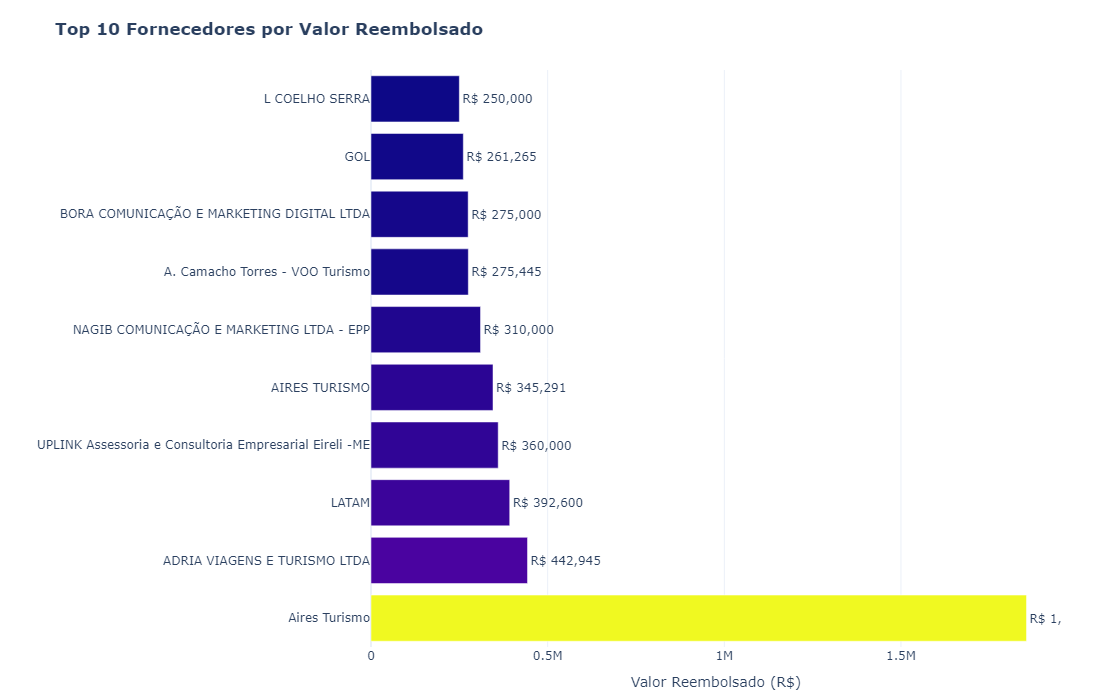

In [90]:
fig_fornecedores = px.bar(

    top_fornecedores,

    x="TOTAL",
    y="NOME_FORNECEDOR",

    orientation="h",

    text="TOTAL",

    color="TOTAL",

    template="plotly_white",

    title="<b>Top 10 Fornecedores por Valor Reembolsado</b>"
)

fig_fornecedores.update_traces(

    texttemplate="R$ %{text:,.0f}",
    textposition="outside"

)

fig_fornecedores.update_layout(

    height=700,

    yaxis_title="",

    xaxis_title="Valor Reembolsado (R$)",

    coloraxis_showscale=False,

    margin=dict(
        l=260,
        r=40,
        t=70,
        b=40
    )

)

fig_fornecedores.show()

## Principais Observações

- O ranking evidencia os principais fornecedores da CEAPS em 2023.

- A concentração dos pagamentos permite identificar empresas com maior participação nos reembolsos realizados pelos gabinetes parlamentares.

- Os fornecedores abrangem diferentes segmentos de serviços necessários ao exercício da atividade parlamentar.

## Conclusões

A análise dos fornecedores demonstra a distribuição dos pagamentos entre empresas e prestadores de serviços, constituindo um importante indicador da execução dos recursos da CEAPS.

# 10. Evolução Mensal dos Reembolsos

Esta seção apresenta a evolução dos valores reembolsados ao longo dos meses de 2023.

A análise permite identificar padrões sazonais, oscilações e períodos de maior execução dos recursos.

In [95]:
display(gastos_mes)

,MÊS,TOTAL,MES_NOME
0,1,"1,906,656.75",Jan
1,2,"1,916,953.59",Fev
2,3,"2,612,843.04",Mar
3,4,"2,269,650.49",Abr
4,5,"2,418,296.67",Mai
5,6,"2,339,721.60",Jun
6,7,"2,060,572.07",Jul
7,8,"2,668,085.13",Ago
8,9,"2,449,310.63",Set
9,10,"2,473,759.80",Out


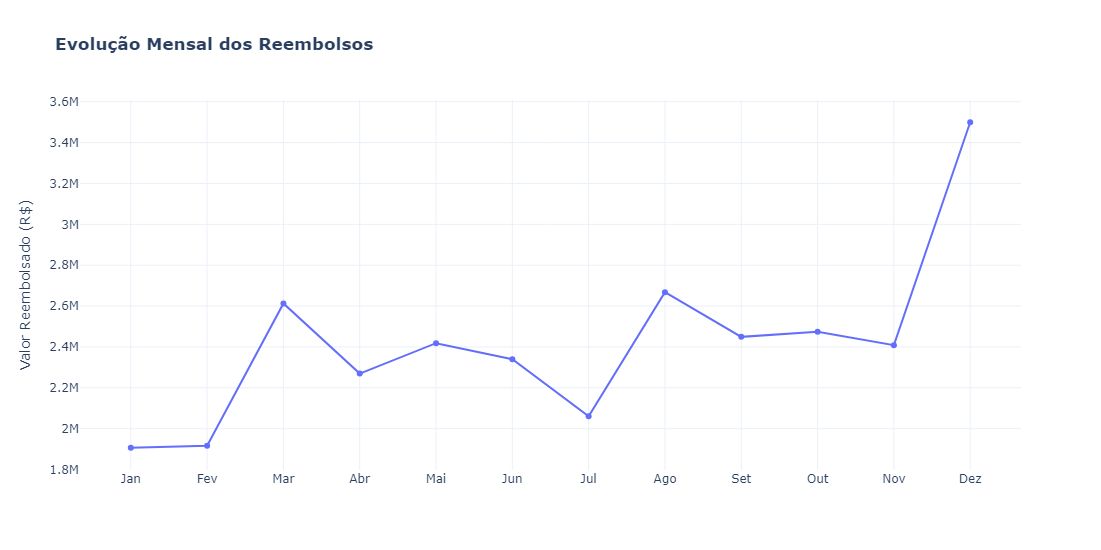

In [97]:
fig_mes = px.line(

    gastos_mes,

    x="MES_NOME",

    y="TOTAL",

    markers=True,

    template="plotly_white",

    title="<b>Evolução Mensal dos Reembolsos</b>"
)

fig_mes.update_layout(

    height=550,

    xaxis_title="",

    yaxis_title="Valor Reembolsado (R$)"
)

fig_mes.show()

## Principais Observações

- A evolução mensal evidencia o comportamento dos reembolsos ao longo do ano.

- As oscilações observadas podem estar relacionadas ao calendário legislativo e à dinâmica das atividades parlamentares.

- A identificação dos meses de maior e menor gasto contribui para análises comparativas entre exercícios.

## Conclusões

A série temporal permite compreender a distribuição dos reembolsos durante o exercício e identificar tendências que poderão ser comparadas com os demais anos da série histórica.

# 11. Heatmap das Categorias de Despesas

O heatmap apresenta a distribuição dos valores reembolsados por categoria de despesa e por mês.

Essa visualização facilita a identificação de padrões de concentração e variações ao longo do exercício.

In [102]:
display(heatmap)

MÊS,1,2,3,4,5,6,7,8,9,10,11,12
TIPO_DESPESA,,,,,,,,,,,,
"Aluguel de imóveis para escritório político, compreendendo despesas concernentes a eles.","308,641.41","284,233.53","393,325.10","397,709.62","381,475.47","373,146.03","355,599.90","410,916.07","344,121.56","419,593.54","371,437.68","383,193.32"
"Aquisição de material de consumo para uso no escritório político, inclusive aquisição ou locação de software, despesas postais, aquisição de publicações, locação de móveis e de equipamentos.","63,790.54","52,536.00","88,425.00","68,355.09","74,574.29","83,990.50","86,570.28","86,097.91","90,058.15","100,281.98","84,121.32","113,290.51"
"Contratação de consultorias, assessorias, pesquisas, trabalhos técnicos e outros serviços de apoio ao exercício do mandato parlamentar","412,337.08","492,701.76","678,149.30","560,625.76","579,119.42","517,967.96","436,029.20","680,280.70","603,941.43","530,676.71","480,928.65","1,192,525.75"
Divulgação da atividade parlamentar,"170,896.65","189,046.57","330,451.96","334,915.40","286,520.00","344,950.80","294,056.50","281,966.42","381,868.30","345,800.80","378,457.71","914,213.76"
"Locomoção, hospedagem, alimentação, combustíveis e lubrificantes","449,893.40","388,532.17","582,696.51","535,527.96","570,930.98","606,956.84","502,378.08","573,602.01","560,653.31","607,700.73","605,651.55","573,221.70"
"Passagens aéreas, aquáticas e terrestres nacionais","490,551.02","508,898.56","528,975.23","359,555.87","504,401.53","392,212.53","371,313.92","610,791.96","444,711.39","435,896.75","459,500.12","296,931.92"
Serviços de Segurança Privada,"1,089.98","1,005.00",238.16,717.94,380.68,296.94,NaN,NaN,180.00,NaN,NaN,NaN


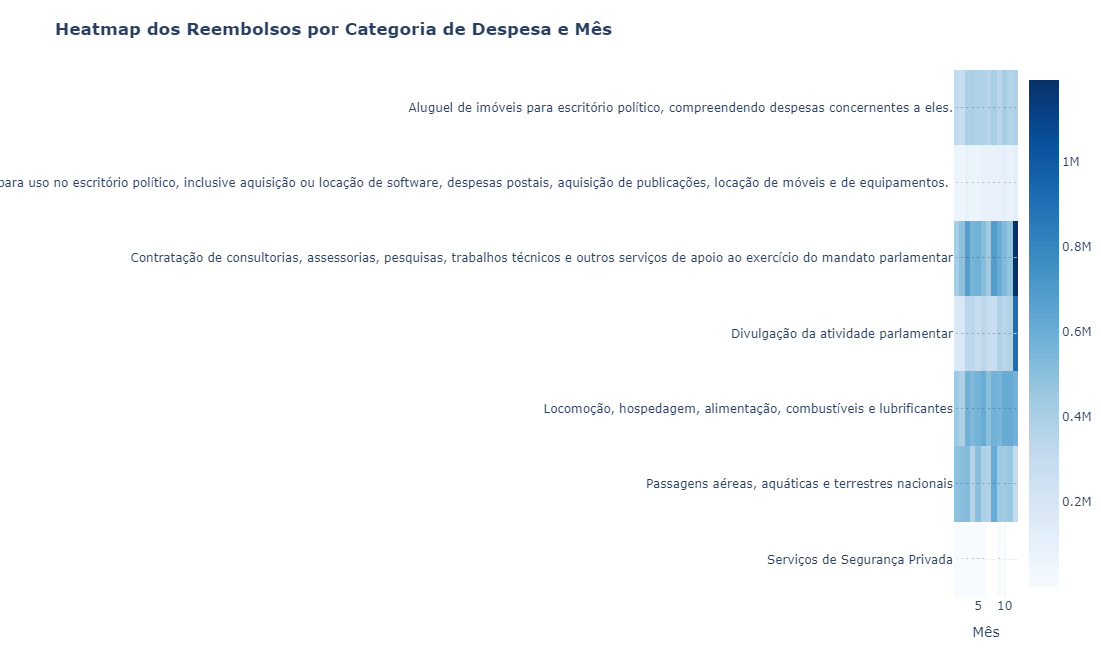

In [106]:
# =====================================================
# Heatmap - Categorias x Meses
# =====================================================

import plotly.express as px

fig_heatmap = px.imshow(

    heatmap,

    text_auto=".2s",

    aspect="auto",

    color_continuous_scale="Blues",

    title="<b>Heatmap dos Reembolsos por Categoria de Despesa e Mês</b>"
)

fig_heatmap.update_layout(

    template="plotly_white",

    height=650,

    margin=dict(
        l=220,
        r=40,
        t=70,
        b=40
    ),

    xaxis_title="Mês",

    yaxis_title=""
)

fig_heatmap.show()

## Principais Observações

- O heatmap evidencia a distribuição dos valores reembolsados por categoria de despesa ao longo dos meses de 2023.

- A intensidade das cores facilita a identificação dos períodos de maior concentração de gastos em cada categoria.

- Observa-se que algumas categorias apresentam comportamento relativamente constante durante o ano, enquanto outras apresentam maior sazonalidade.

- Essa visualização permite identificar rapidamente padrões que seriam menos perceptíveis em tabelas convencionais.

## Conclusões

O heatmap complementa as análises anteriores ao apresentar simultaneamente a dimensão temporal e a distribuição dos gastos por categoria.

Essa abordagem permite identificar padrões de concentração dos reembolsos, contribuindo para uma compreensão mais abrangente da execução da CEAPS durante o exercício de 2023 e fornecendo subsídios para futuras análises comparativas entre diferentes anos.

# 12. Dashboard Executivo

O dashboard reúne os principais indicadores e visualizações desenvolvidos ao longo desta análise em uma única interface.

Seu objetivo é fornecer uma visão consolidada da execução da CEAPS em 2023, permitindo rápida identificação dos principais padrões de gastos públicos, categorias de despesas, fornecedores, parlamentares e evolução mensal dos reembolsos.

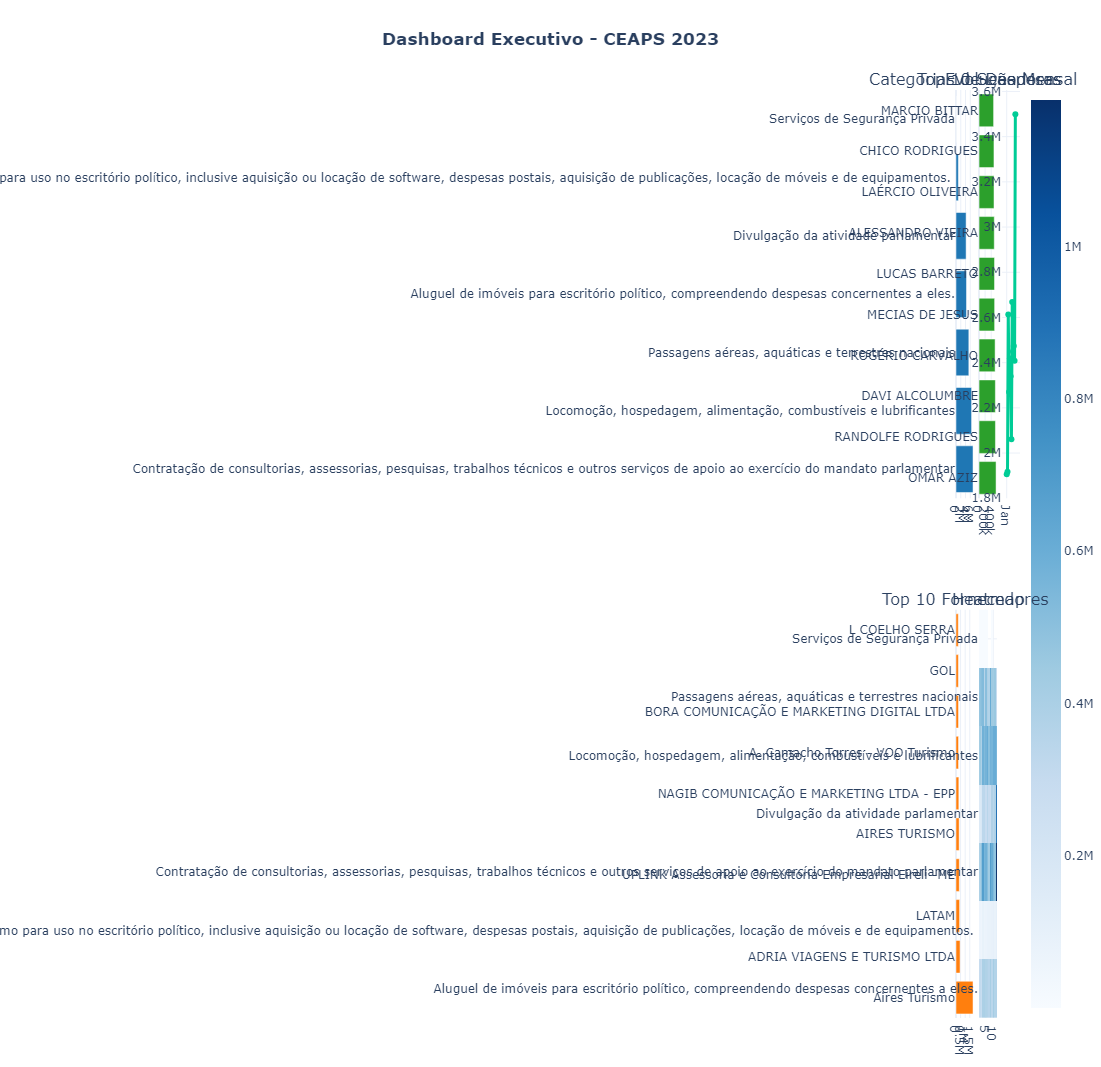

In [129]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# -----------------------------------------------------------------
# Criação do Dashboard
# -----------------------------------------------------------------

dashboard = make_subplots(

    rows=2,
    cols=3,

    subplot_titles=(

        "Categorias de Despesas",

        "Top 10 Senadores",

        "Evolução Mensal",

        "Top 10 Fornecedores",

        "Heatmap",

        ""

    ),

    specs=[

        [{"type":"bar"},
         {"type":"bar"},
         {"type":"scatter"}],

        [{"type":"bar"},
         {"type":"heatmap"},
         None]

    ],

    horizontal_spacing=0.08,
    vertical_spacing=0.12
)

# -----------------------------------------------------------------
# Categorias
# -----------------------------------------------------------------

dashboard.add_trace(

    go.Bar(

        x=despesas_categoria["TOTAL"],
        y=despesas_categoria["TIPO_DESPESA"],

        orientation="h",

        marker_color="#1f77b4",

        showlegend=False

    ),

    row=1,
    col=1

)

# -----------------------------------------------------------------
# Senadores
# -----------------------------------------------------------------

dashboard.add_trace(

    go.Bar(

        x=top_senadores["TOTAL"],
        y=top_senadores["NOME_SENADOR"],

        orientation="h",

        marker_color="#2ca02c",

        showlegend=False

    ),

    row=1,
    col=2

)

# -----------------------------------------------------------------
# Evolução Mensal
# -----------------------------------------------------------------

dashboard.add_trace(

    go.Scatter(

        x=gastos_mes["MES_NOME"],
        y=gastos_mes["TOTAL"],

        mode="lines+markers",

        line=dict(width=3),

        showlegend=False

    ),

    row=1,
    col=3

)

# -----------------------------------------------------------------
# Fornecedores
# -----------------------------------------------------------------

dashboard.add_trace(

    go.Bar(

        x=top_fornecedores["TOTAL"],
        y=top_fornecedores["NOME_FORNECEDOR"],

        orientation="h",

        marker_color="#ff7f0e",

        showlegend=False

    ),

    row=2,
    col=1

)

# -----------------------------------------------------------------
# Heatmap
# -----------------------------------------------------------------

dashboard.add_trace(

    go.Heatmap(

        z=heatmap.values,

        x=heatmap.columns,

        y=heatmap.index,

        colorscale="Blues",

        showscale=True

    ),

    row=2,
    col=2

)

# -----------------------------------------------------------------
# Layout Geral
# -----------------------------------------------------------------

dashboard.update_layout(

    title={

        "text":"<b>Dashboard Executivo - CEAPS 2023</b>",

        "x":0.5

    },

    template="plotly_white",

    height=1050,

    width=1800,

    margin=dict(

        l=40,

        r=40,

        t=90,

        b=40

    ),

    showlegend=False

)

dashboard.update_yaxes(automargin=True)
dashboard.update_xaxes(automargin=True)

dashboard.show()

## Principais Observações

- O dashboard consolida todas as análises desenvolvidas ao longo do projeto em uma única interface interativa.

- A visualização integrada permite identificar rapidamente a distribuição dos gastos por categoria, senador, fornecedor e mês, além dos padrões observados no heatmap.

- A combinação de indicadores e gráficos facilita a interpretação dos dados e torna a análise mais acessível para diferentes públicos.

## Conclusões

O dashboard executivo representa a síntese visual de toda a análise realizada para a CEAPS 2023.

Sua estrutura permite explorar diferentes perspectivas dos dados de maneira integrada, apoiando a identificação de padrões, concentrações de gastos e tendências temporais. Esse painel também estabelece um modelo padronizado para as análises dos anos seguintes, garantindo consistência metodológica em toda a série histórica do projeto.

# 13. Análise Executiva

A análise dos reembolsos da CEAPS referentes ao exercício de 2023 evidencia que a maior parte dos recursos públicos concentrou-se em um número reduzido de categorias de despesas, principalmente aquelas relacionadas ao funcionamento dos gabinetes parlamentares, deslocamentos oficiais e contratação de serviços especializados.

A distribuição dos gastos demonstra um comportamento relativamente consistente ao longo do exercício, com variações mensais compatíveis com a dinâmica das atividades legislativas.

A concentração dos reembolsos em determinados fornecedores e categorias permite compreender como os recursos são operacionalizados durante o mandato parlamentar.

De forma geral, os dados analisados apresentam boa qualidade, permitindo a construção de indicadores confiáveis e visualizações capazes de apoiar análises comparativas entre diferentes exercícios.

# 14. Principais Insights

## Principais Resultados

- A maior parte dos recursos concentrou-se em poucas categorias de despesas.

- As despesas relacionadas ao funcionamento dos gabinetes permaneceram predominantes durante todo o exercício.

- Os reembolsos apresentaram comportamento relativamente estável ao longo dos meses, sem oscilações incompatíveis com a atividade parlamentar.

- Os principais fornecedores concentraram parcela significativa dos pagamentos realizados pela CEAPS.

- A estrutura dos gastos observada em 2023 fornece uma base consistente para comparações com os exercícios de 2021, 2022 e 2024.

# 15. Conclusão

Este projeto apresentou uma análise exploratória dos reembolsos da CEAPS referentes ao exercício de 2023 utilizando Python, Pandas e Plotly.

Ao longo do trabalho foram realizadas etapas de limpeza, preparação, exploração dos dados, construção de indicadores, elaboração de visualizações interativas e desenvolvimento de um dashboard executivo.

Os resultados obtidos permitem compreender a distribuição dos gastos parlamentares sob diferentes perspectivas, contribuindo para a transparência e para a interpretação das informações disponibilizadas pelo Senado Federal.

A metodologia desenvolvida neste projeto será utilizada como base para a análise dos demais exercícios da série histórica, permitindo a construção de estudos comparativos entre os anos de 2021 a 2024.

# 16. Exportação e Publicação

Após a conclusão da análise, o notebook foi exportado para HTML e os principais gráficos foram salvos em formato PNG para composição da documentação do projeto.

Todo o código-fonte, documentação e visualizações foram organizados e publicados no GitHub como parte do portfólio de projetos em Ciência de Dados.

# 17. Próximos Passos

Como continuidade deste trabalho, pretende-se:

- realizar a análise do exercício de 2024 utilizando a mesma metodologia;

- construir uma análise comparativa consolidando os exercícios de 2021, 2022, 2023 e 2024;

- desenvolver visualizações comparativas entre mandatos, categorias de despesas, fornecedores e parlamentares;

- ampliar o projeto com indicadores temporais e análises estatísticas que permitam identificar tendências na utilização da CEAPS ao longo dos anos.

> **Status do Projeto:** Concluído ✅
>
> Este projeto apresenta uma análise exploratória dos reembolsos da CEAPS referentes ao exercício de 2023, utilizando Python, Pandas e Plotly. A estrutura desenvolvida neste notebook servirá como modelo para a análise dos demais exercícios da série histórica (2021–2024).

In [143]:
fig_categoria.write_image(
    "images/categorias.png",
    width=1600,
    height=900,
    scale=2
)

fig_senadores.write_image(
    "images/senadores.png",
    width=1600,
    height=900,
    scale=2
)

fig_fornecedores.write_image(
    "images/fornecedores.png",
    width=1600,
    height=900,
    scale=2
)

fig_mes.write_image(
    "images/mes.png",
    width=1600,
    height=900,
    scale=2
)

fig_heatmap.write_image(
    "images/heatmap.png",
    width=1600,
    height=900,
    scale=2
)

print("Gráficos 2023 exportados com sucesso!")

Gráficos 2023 exportados com sucesso!
